In [28]:
import dill as pk
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from astropy.time import Time
import datetime as dt
import glob
from pathlib import Path

from sotodlib import core
from sotodlib.core.metadata.loader import LoaderError
from sotodlib.tod_ops.flags import get_det_bias_flags

from latcom.utils import yield_utils as yd
from latcom.utils.parsing import parse_dict
from latcom.utils.cut_utils import get_cut_sources, get_det_cal_cuts, get_yield_stages, get_det_bias_cuts
from latcom.utils.optical_loading import (
    aso_tubes,
    lf_tubes,
    ot_from_ufm,
    pwv_interp,
    so_nominal_tubes,
)

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [85]:
ctx = core.Context("../../ctxs/smurf_det_preproc.yaml")
ufm = "mv11"
band = "150"
ot = ot_from_ufm(ufm)

start = dt.datetime(2026, 6, 1, tzinfo=dt.timezone.utc)
end = dt.datetime(2026, 7, 15, tzinfo=dt.timezone.utc)


obs_list = ctx.obsdb.query(
    f"{end.timestamp()} > timestamp and timestamp > {start.timestamp()} and type=='obs' and subtype=='cmb'"
)


pwv = pwv_interp()

obs_ctx_list = []
for i, obs in enumerate(obs_list):
    cur_ot = str(obs["obs_id"]).split("_")[2][3:]
    obs_id = str(obs["obs_id"])
    if cur_ot in lf_tubes:
        obs_ctx_list.append((obs_id, "../../ctxs/preprocess_lf_260604.yaml"))
    else:
        obs_ctx_list.append((obs_id, "../../ctxs/preprocess_260604.yaml"))

In [86]:
for (obs_id, ctx_path) in obs_ctx_list:
    if ot in obs_id:
        print(obs_id)
        ctx = core.Context(ctx_path)
        break
aso_metas = []
for (obs_id, ctx_path) in obs_ctx_list:
    if ot in obs_id:
        print(obs_id)
        try:
            meta = ctx.get_meta(obs_id,dets={"dets:stream_id": "ufm_" + str(ufm), "dets:wafer.bandpass": "f" + str(band),},)
            aso_metas.append(meta)
            
        except:
            continue

obs_1780272171_lati6_111
obs_1780272171_lati6_111


/global/u2/j/jorlo/dev/sotodlib/sotodlib/core/metadata/loader.py:996: MetadataSpecWarning: metadata spec contains 'unpack' and 'name' entries; ignoring the latter (except to set the 'label', maybe).
  warnings.warn(


obs_1780277754_lati6_111
obs_1780280083_lati6_111


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/users/mmccrack/so/det_match/lat/260204_aso/aso/focal_planes_260517/results//assignment.sqlite', 'label': 'assignment', 'det_info': True, 'on_missing': 'trim'}

  request: {'obs:obs_id': 'obs_1780283695_lati6_110', 'dets:stream_id': 'ufm_mv11', 'dets:wafer.bandpass': 'f150'}


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/users/mmccrack/so/det_match/lat/260204_aso/aso/focal_planes_260517/results//assignment.sqlite', 'label': 'assignment', 'det_info': True, 'on_missing': 'trim'}

  request: {'obs:obs_id': 'obs_1780288319_lati6_110', 'dets:stream_id': 'ufm_mv11', 'dets:wafer.bandpass': 'f150'}




obs_1780283695_lati6_110
obs_1780288319_lati6_110
obs_1780292197_lati6_110


...

ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/lat-iso/aso/v2/preprocessing/archives//process_archive.sqlite', 'label': 'preprocess', 'unpack': 'preprocess'}

  request: {'obs:obs_id': 'obs_1784049699_lati6_111', 'dets:stream_id': 'ufm_mv11', 'dets:wafer.bandpass': 'f150'}




obs_1784052344_lati6_111


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/lat-iso/aso/v2/preprocessing/archives//process_archive.sqlite', 'label': 'preprocess', 'unpack': 'preprocess'}

  request: {'obs:obs_id': 'obs_1784052344_lati6_111', 'dets:stream_id': 'ufm_mv11', 'dets:wafer.bandpass': 'f150'}




obs_1784056649_lati6_111


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/lat-iso/aso/v2/preprocessing/archives//process_archive.sqlite', 'label': 'preprocess', 'unpack': 'preprocess'}

  request: {'obs:obs_id': 'obs_1784056649_lati6_111', 'dets:stream_id': 'ufm_mv11', 'dets:wafer.bandpass': 'f150'}




In [87]:
det_bias_cuts = get_det_bias_cuts(aso_metas[0])
cut_names = det_bias_cuts.keys()
obs_ids = []
times = []
n_cuts = np.zeros((len(cut_names), len(aso_metas)))
pwvs = []

for i, meta in enumerate(aso_metas):
    obs_id = meta.obs_info.obs_id
    obs_ids.append(obs_id.split("_")[1])
    times.append(dt.datetime.fromtimestamp(int(obs_id.split("_")[1])))
    pwvs.append(pwv(obs_id.split("_")[1]))
    det_bias_cuts = get_det_bias_cuts(meta)
    n_cuts[..., i] = np.array(list(det_bias_cuts.values()), dtype=float)


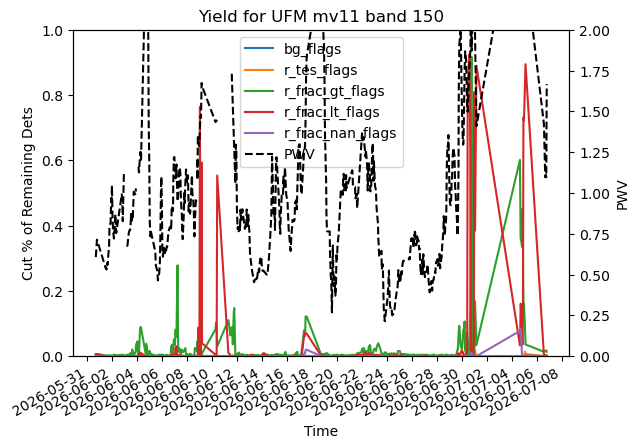

In [88]:
import matplotlib.dates as mdates

fig, ax = plt.subplots()
lns = []
for cut_name, n_cut in zip(cut_names, n_cuts):
    cur_ln = ax.plot(times, n_cut, label=cut_name)
    lns += cur_ln
        
ax2 = ax.twinx()
pw = ax2.plot(times, pwvs, label="PWV", c="black", alpha=1, linestyle="--")

ax.set_xlabel("Time")
ax.set_ylabel("Cut % of Remaining Dets")
ax.set_ylim(0, 1)
ax2.set_ylim(0, 2)
ax2.set_ylabel("PWV")

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.gcf().autofmt_xdate()

lns = lns + pw
labs = [l.get_label() for l in lns]
ax.legend(lns, labs)
plt.title(f"Yield for UFM {ufm} band {band}")
output_dir = Path(f"../../plts/indv_ufms/{ufm}/")
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / f"det_bias_cuts_{ufm}_{band}.pdf", dpi=600)
plt.savefig(output_dir / f"det_bias_cuts_{ufm}_{band}.png", dpi=600)

plt.show()

In [80]:
plt.hist(meta.det_cal.phase_to_pW[net_flag], bins=np.linspace(0, 0.15, 10))
plt.title("Phi-conv for {} {} for obs {}".format(ufm, band, obs_id.split("_")[1]))
plt.xlabel("Phase to pW")
output_dir = Path(f"../../plts/indv_ufms/{ufm}/")
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir/f"Phiconv_{ufm}_{band}.pdf", dpi=600)
plt.savefig(output_dir/f"Phiconv_{ufm}_{band}.png", dpi=600)

NameError: name 'net_flag' is not defined

In [ ]:
plt.hist(wnoise, bins=np.linspace(0, 40, 10))
plt.axvline(17.7, label="goal", c='green')
plt.axvline(24.0, label="baseline", c='red')
plt.legend()
plt.title("NEPs for {} {} for obs {}".format(ufm, band, obs_id.split("_")[1]))
plt.xlabel("NEP (aW/rtHz)")

output_dir = Path(f"../../plts/indv_ufms/{ufm}/")
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir/f"NEP_{ufm}_{band}.pdf", dpi=600)
plt.savefig(output_dir/f"NEP_{ufm}_{band}.png", dpi=600)

In [ ]:
obs_id

# SO Nominal 

In [26]:
start = dt.datetime(2025, 10, 1, tzinfo=dt.timezone.utc)
end = dt.datetime(2025, 10, 15, tzinfo=dt.timezone.utc)


obs_list = ctx.obsdb.query(
    f"{end.timestamp()} > timestamp and timestamp > {start.timestamp()} and type=='obs' and subtype=='cmb'"
)

obs_ids_list = []
for i, obs in enumerate(obs_list):
    obs_ids_list.append(str(obs["obs_id"]))

In [27]:
old_ctx = core.Context("../../ctxs/old_smurf_det_preproc.yaml")
nominal_metas = []
for obs_id in obs_ids_list:
    if ot in obs_id:
        print(obs_id)
        try:
            meta = old_ctx.get_meta(obs_id,dets={"dets:stream_id": "ufm_" + str(ufm), "dets:wafer.bandpass": "f" + str(band),},)
            nominal_metas.append(meta)
            
        except:
            continue

obs_1759277309_lati4_111
obs_1759279469_lati4_111
obs_1759283082_lati4_111
obs_1759286672_lati4_111
obs_1759291142_lati4_111
obs_1759293429_lati4_111
obs_1759297035_lati4_111
obs_1759300634_lati4_111
obs_1759304241_lati4_111
obs_1759307681_lati4_111
obs_1759309856_lati4_111
obs_1759313445_lati4_111
obs_1759319136_lati4_111
obs_1759321587_lati4_111
obs_1759325207_lati4_111
obs_1759332347_lati4_111
obs_1759337257_lati4_111
obs_1759339814_lati4_111
obs_1759352281_lati4_111
obs_1759354032_lati4_111
obs_1759357620_lati4_111
obs_1759367543_lati4_111
obs_1759369163_lati4_111
obs_1759372751_lati4_111
obs_1759377299_lati4_111
obs_1759379466_lati4_111
obs_1759383059_lati4_111
obs_1759386659_lati4_111
obs_1759390265_lati4_111
obs_1759393847_lati4_111
obs_1759395572_lati4_111
obs_1759399155_lati4_111
obs_1759404891_lati4_111
obs_1759407263_lati4_111
obs_1759410834_lati4_111
obs_1759438885_lati4_111
obs_1759441252_lati4_111
obs_1759444834_lati4_111
obs_1759448377_lati4_111
obs_1759450536_lati4_111


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/metadata/lat/manifests/preprocess/lat_preprocess_cmb_240409m/process_archive.sqlite', 'label': 'preprocess', 'unpack': 'preprocess', 'drop_fields': ['frequency_cutoffs', 'gain_avg']}

  request: {'obs:obs_id': 'obs_1759641864_lati4_111', 'dets:stream_id': 'ufm_mv49', 'dets:wafer.bandpass': 'f090'}




obs_1759645464_lati4_111


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/metadata/lat/manifests/preprocess/lat_preprocess_cmb_240409m/process_archive.sqlite', 'label': 'preprocess', 'unpack': 'preprocess', 'drop_fields': ['frequency_cutoffs', 'gain_avg']}

  request: {'obs:obs_id': 'obs_1759645464_lati4_111', 'dets:stream_id': 'ufm_mv49', 'dets:wafer.bandpass': 'f090'}




obs_1759649066_lati4_111


...

obs_1760342959_lati4_011
obs_1760347612_lati4_011


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/metadata/lat/manifests/preprocess/lat_preprocess_cmb_240409m/process_archive.sqlite', 'label': 'preprocess', 'unpack': 'preprocess', 'drop_fields': ['frequency_cutoffs', 'gain_avg']}

  request: {'obs:obs_id': 'obs_1760347612_lati4_011', 'dets:stream_id': 'ufm_mv49', 'dets:wafer.bandpass': 'f090'}




obs_1760350212_lati4_011
obs_1760352771_lati4_011
obs_1760354574_lati4_011
obs_1760358154_lati4_011
obs_1760362804_lati4_011
obs_1760365375_lati4_011
obs_1760368945_lati4_011
obs_1760372556_lati4_011
obs_1760375819_lati4_011
obs_1760379753_lati4_011


ERROR: sotodlib.core.metadata.loader: An error occurred while processing a meta entry:

  spec:    {'db': '/global/cfs/cdirs/sobs/metadata/lat/manifests/preprocess/lat_preprocess_cmb_240409m/process_archive.sqlite', 'label': 'preprocess', 'unpack': 'preprocess', 'drop_fields': ['frequency_cutoffs', 'gain_avg']}

  request: {'obs:obs_id': 'obs_1760382339_lati4_011', 'dets:stream_id': 'ufm_mv49', 'dets:wafer.bandpass': 'f090'}




obs_1760382339_lati4_011
obs_1760385904_lati4_011
obs_1760389778_lati4_011
obs_1760391754_lati4_011
obs_1760395472_lati4_011
obs_1760398532_lati4_011
obs_1760413537_lati4_111
obs_1760414643_lati4_111
obs_1760418111_lati4_111
obs_1760422471_lati4_111
obs_1760424904_lati4_111
obs_1760429552_lati4_111
obs_1760432126_lati4_111
obs_1760435696_lati4_111
obs_1760438975_lati4_111
obs_1760441200_lati4_111
obs_1760445841_lati4_111
obs_1760448413_lati4_111
obs_1760451976_lati4_111
obs_1760455590_lati4_111
obs_1760459186_lati4_111
obs_1760463336_lati4_111
obs_1760465802_lati4_111
obs_1760469402_lati4_111
obs_1760473001_lati4_111
obs_1760475937_lati4_111
obs_1760477904_lati4_111
obs_1760481993_lati4_111
obs_1760484766_lati4_111


In [28]:
i = -1
meta = nominal_metas[i]
obs_id = meta.obs_info.obs_id
if "mv" in ufm:
    if band == "090":
        ufm_band = 1
    elif band == "150":
        ufm_band = 2
if "uv" in ufm:
    if band == "220":
        ufm_band = 1
    elif band == "280":
        ufm_band = 2
flags = get_det_bias_flags(meta).det_bias_flags
print("Cut to any flag: ", len([flag for flag in np.any(flags.mask(), axis=-1) if flag]))
meta.restrict("dets", ~core.flagman.has_any_cuts(flags))
wafer_flag = np.array([ufm in _ufm for _ufm in meta.det_info.stream_id])

if len(wafer_flag) == 0:
    print(f"No det_info for obs {obs_id}")
bp = (meta.det_cal.bg % 4) // 2

if ufm_band == 1:
    net_flag = wafer_flag * (bp == 0)
elif ufm_band == 2:
    net_flag = wafer_flag * (bp == 1)
wnoise = meta.preprocess.noise.white_noise[net_flag] * 1e6
ndet = len(np.where(wnoise != 0)[0])
print("Cut to white noise: ", len(np.any(flags.mask(), axis=-1))-len([flag for flag in np.any(flags.mask(), axis=-1) if flag])-ndet)

Cut to any flag:  19
Cut to white noise:  1


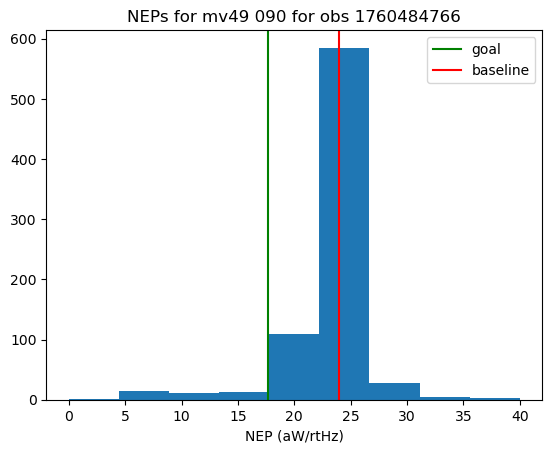

In [29]:
plt.hist(wnoise, bins=np.linspace(0, 40, 10))
plt.axvline(17.7, label="goal", c='green')
plt.axvline(24.0, label="baseline", c='red')
plt.legend()
plt.title("NEPs for {} {} for obs {}".format(ufm, band, obs_id.split("_")[1]))
plt.xlabel("NEP (aW/rtHz)")

output_dir = Path(f"../../plts/indv_ufms/{ufm}/")
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir/f"old_NEP_{ufm}_{band}.pdf", dpi=600)
plt.savefig(output_dir/f"old_NEP_{ufm}_{band}.png", dpi=600)

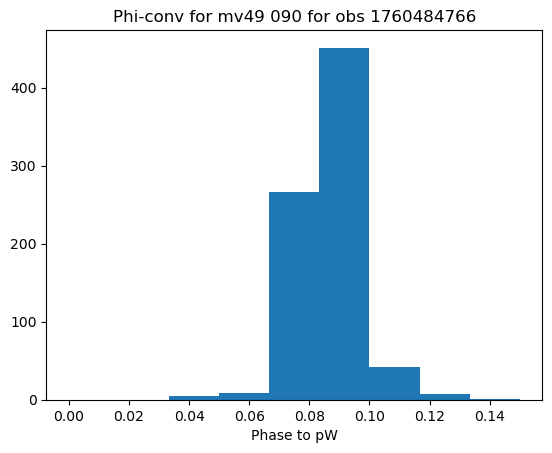

In [30]:
plt.hist(meta.det_cal.phase_to_pW[net_flag], bins=np.linspace(0, 0.15, 10))
plt.title("Phi-conv for {} {} for obs {}".format(ufm, band, obs_id.split("_")[1]))
plt.xlabel("Phase to pW")
output_dir = Path(f"../../plts/indv_ufms/{ufm}/")
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir/f"old_Phiconv_{ufm}_{band}.pdf", dpi=600)
plt.savefig(output_dir/f"old_Phiconv_{ufm}_{band}.png", dpi=600)

In [11]:
ndet

780